In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import time
import matplotlib.pyplot as plt

In [27]:
torch.manual_seed(42)

class SGDRegressor(nn.Module):
    def __init__(self, input_dim):
        super(SGDRegressor, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

In [28]:
torch.manual_seed(42)

model = SGDRegressor(input_dim=1)
print("Initial parameters:")
for name, param in model.named_parameters():
    print(f"Name: {name}, Value: {param.data}")

optimizer_fixed = optim.SGD(model.parameters(), lr=0.001) 
loss_fn = nn.MSELoss()

# Use the same training data but ensure it's properly scaled
X_train = torch.rand(100, 1) * 20  # Keep the same scale for now
y_train = 2 + 3 * X_train + torch.randn(100, 1) * 0.5

print(f"Training data range - X: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Training data range - y: [{y_train.min():.2f}, {y_train.max():.2f}]")

Initial parameters:
Name: linear.weight, Value: tensor([[0.7645]])
Name: linear.bias, Value: tensor([0.8300])
Training data range - X: [0.08, 19.62]
Training data range - y: [1.94, 60.22]


In [29]:
EPOCHS = 1000
losses = []

for epoch in tqdm(range(EPOCHS)):
    model.train()
    
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    losses.append(loss.item())
    
    optimizer_fixed.zero_grad()
    loss.backward()
    optimizer_fixed.step()

print("Training completed successfully!")
print(f"Final loss: {losses[-1]:.4f}")

# Check the final parameters
print("\nFinal parameters:")
for name, param in model.named_parameters():
    print(f"Name: {name}, Value: {param.data}")

100%|██████████| 1000/1000 [00:00<00:00, 1635.69it/s]

Training completed successfully!
Final loss: 0.2717

Final parameters:
Name: linear.weight, Value: tensor([[3.0376]])
Name: linear.bias, Value: tensor([1.4371])


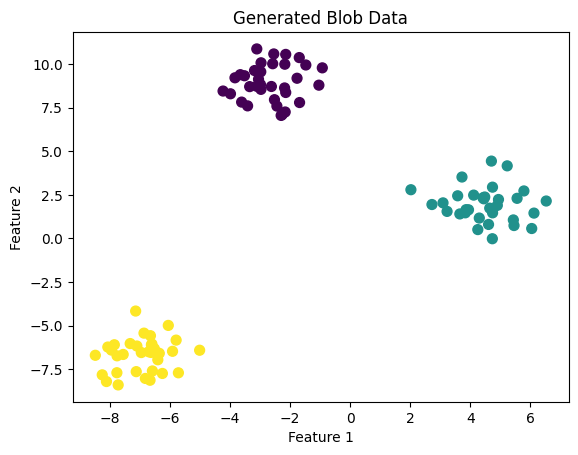

In [32]:
## Genrate Blob data
X, y = make_blobs(n_samples=100, centers=3, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)
# Visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50)
plt.title('Generated Blob Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [33]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

In [40]:
model = LogisticRegression(input_dim=2, output_dim=3)
optimizer = optim.SGD(model.parameters(), lr=0.01)

loss_fn = nn.CrossEntropyLoss()

EPOCHS = 1000

In [38]:
# Training loop
losses = []
for epoch in tqdm(range(EPOCHS)):
    model.train()

    y_pred = model(X)  
    loss = loss_fn(y_pred, y) 
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

print(f"\nTraining completed! Final loss: {losses[-1]:.4f}")

 23%|██▎       | 228/1000 [00:00<00:00, 1206.22it/s]

Epoch 0, Loss: 9.4156
Epoch 100, Loss: 0.0705
Epoch 200, Loss: 0.0344


 53%|█████▎    | 533/1000 [00:00<00:00, 1446.92it/s]

Epoch 300, Loss: 0.0232
Epoch 400, Loss: 0.0178
Epoch 500, Loss: 0.0145
Epoch 600, Loss: 0.0123


 68%|██████▊   | 678/1000 [00:00<00:00, 1408.04it/s]

Epoch 700, Loss: 0.0107
Epoch 800, Loss: 0.0095


100%|██████████| 1000/1000 [00:00<00:00, 1125.51it/s]

Epoch 900, Loss: 0.0086

Training completed! Final loss: 0.0078


Classification Accuracy: 1.0000 (100.00%)


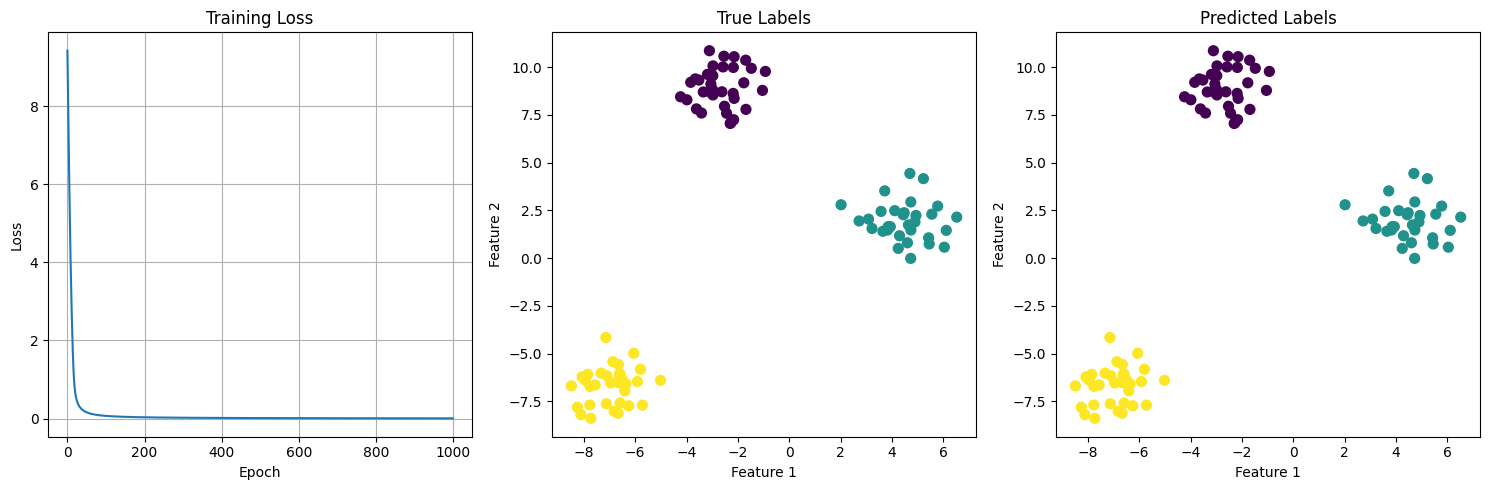


Sample Predictions:
Index | True | Pred | Confidence
-----------------------------------
    0 |    2 |    2 |   0.9995 ✓
    1 |    1 |    1 |   0.9983 ✓
    2 |    0 |    0 |   0.9988 ✓
    3 |    1 |    1 |   0.9992 ✓
    4 |    2 |    2 |   0.9967 ✓
    5 |    1 |    1 |   0.9823 ✓
    6 |    0 |    0 |   0.9973 ✓
    7 |    1 |    1 |   0.9918 ✓
    8 |    1 |    1 |   0.9935 ✓
    9 |    0 |    0 |   0.9994 ✓


In [39]:
# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred_logits = model(X)
    y_pred_probs = F.softmax(y_pred_logits, dim=1)
    y_pred_classes = torch.argmax(y_pred_logits, dim=1)

# Calculate accuracy
accuracy = (y_pred_classes == y).float().mean()
print(f"Classification Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Visualize results
plt.figure(figsize=(15, 5))

# Plot 1: Training Loss
plt.subplot(1, 3, 1)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Plot 2: True Labels
plt.subplot(1, 3, 2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50)
plt.title('True Labels')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Plot 3: Predicted Labels
plt.subplot(1, 3, 3)
plt.scatter(X[:, 0], X[:, 1], c=y_pred_classes, cmap='viridis', s=50)
plt.title('Predicted Labels')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Show some predictions vs actual
print("\nSample Predictions:")
print("Index | True | Pred | Confidence")
print("-" * 35)
for i in range(10):
    true_label = y[i].item()
    pred_label = y_pred_classes[i].item()
    confidence = y_pred_probs[i, pred_label].item()
    match = "✓" if true_label == pred_label else "✗"
    print(f"{i:5d} | {true_label:4d} | {pred_label:4d} | {confidence:8.4f} {match}")

In [41]:
train = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
)
test = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
)

100%|██████████| 9.91M/9.91M [00:33<00:00, 297kB/s] 

100%|██████████| 28.9k/28.9k [00:00<00:00, 93.7kB/s]

100%|██████████| 1.65M/1.65M [00:08<00:00, 196kB/s] 

100%|██████████| 4.54k/4.54k [00:00<00:00, 1.30MB/s]



In [42]:
for image, label in train:
    print(f"Image shape: {image.shape}, Label: {label}")
    break

Image shape: torch.Size([1, 28, 28]), Label: 5


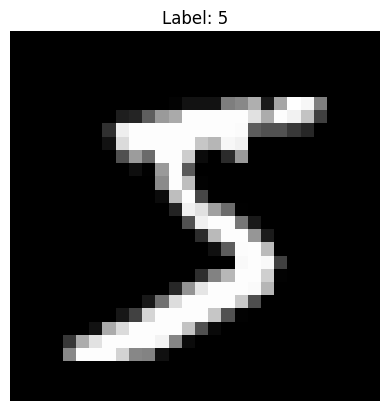

In [43]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.axis('off')
plt.show()

# Neural Network Considerations
When building a Neural Network there are a few things we have to consider:
- **Batch Size:** How many samples do we want to feed through the network at every step?
  - Too large a batch size and we wont be able to fit our data in Memory
  - Too small a batch size, our model wont see a wide enough range of data every time to generalize properly

- **Optimizer:** How will be descend our Cost Curve? The most common optimizer is **Adam** but different problems can benifit from a different optimizer

- **Loss Function:** How do we calculate error? This is highly dependent on the problem! Is it a regression or classification, how many classes do we have, etc...

- **EPOCHS:** How many passes do we want through the entire data? Too few passes and the model will not have learned the weights (Underfitting), too many and the model will have memorized the data (Overfitting)

- **LR:** How quickly do we want to learn? Too fast will be unstable, but too slow will cause training to take more time than necessary


## Overfitting/Underfitting
![image](https://raw.githubusercontent.com/priyammaz/PyTorch-Adventures/main/src/visuals/overfitting_underfitting.jpg)

[credit](https://www.ibm.com/cloud/learn/overfitting)

## Activation Functions
![image](https://miro.medium.com/max/1400/1*ZafDv3VUm60Eh10OeJu1vw.png)

[credit](https://medium.com/@shrutijadon/survey-on-activation-functions-for-deep-learning-9689331ba092)

Lets define some of these below as our starting point

In [52]:
BATCH_SIZE = 64

In [45]:
train_loader = torch.utils.data.DataLoader(
    train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)
test_loader = torch.utils.data.DataLoader(
    test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

In [49]:
for image, label in train_loader:
    print(f"Image shape: {image.shape}")
    break

Image shape: torch.Size([64, 1, 28, 28])


In [51]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.layer(x)

In [59]:
mnist_model = MNISTClassifier()
print(mnist_model)

MNISTClassifier(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [60]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(mnist_model.parameters(), lr=0.001)

In [62]:
# Training loop
losses = []
epoch_losses = []
epoch_accuracies = []

EPOCHS = 5
for epoch in tqdm(range(EPOCHS)):
    mnist_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        outputs = mnist_model(images)
        loss = loss_fn(outputs, labels)
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        losses.append(loss.item())
    
    # Calculate epoch statistics
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    epoch_losses.append(epoch_loss)
    epoch_accuracies.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

 20%|██        | 1/5 [00:08<00:35,  8.79s/it]

Epoch 1/5, Loss: 0.0404, Accuracy: 98.62%


 40%|████      | 2/5 [00:19<00:29,  9.90s/it]

Epoch 2/5, Loss: 0.0359, Accuracy: 98.83%


 60%|██████    | 3/5 [00:33<00:23, 11.91s/it]

Epoch 3/5, Loss: 0.0301, Accuracy: 99.02%


 80%|████████  | 4/5 [00:46<00:12, 12.09s/it]

Epoch 4/5, Loss: 0.0259, Accuracy: 99.13%


100%|██████████| 5/5 [00:55<00:00, 11.18s/it]

Epoch 5/5, Loss: 0.0232, Accuracy: 99.23%


In [63]:
# Testing loop
mnist_model.eval()
test_loss = 0.0
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = mnist_model(images)
        loss = loss_fn(outputs, labels)
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        test_loss += loss.item()
    test_loss /= len(test_loader)
    test_accuracy = 100 * correct / total
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


Test Loss: 0.0891, Test Accuracy: 97.90%
